liberaries

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import scipy.stats as stats
import re
from prophet import Prophet
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dropout
from sklearn.base import clone
from sklearn.model_selection import ParameterGrid
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import plotly.graph_objects as go
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display

load and merge

In [ ]:
energy = pd.read_csv("time_series_60min_singleindex_filtered.csv")
weather = pd.read_csv("era5.csv", header=2)
weather.columns = weather.columns.str.strip()
energy["utc_timestamp"] = pd.to_datetime(energy["utc_timestamp"])
weather = weather.rename(columns={"time": "utc_timestamp"})
weather["utc_timestamp"] = pd.to_datetime(weather["utc_timestamp"], utc=True)
df = pd.merge(energy, weather, on="utc_timestamp", how="inner")
df = df.sort_values("utc_timestamp").set_index("utc_timestamp")

In [ ]:
print(weather.columns)

Index(['utc_timestamp', 'temperature_2m (°C)', 'shortwave_radiation (W/m²)',
       'direct_radiation (W/m²)', 'direct_normal_irradiance (W/m²)',
       'global_tilted_irradiance (W/m²)', 'cloud_cover (%)',
       'cloud_cover_low (%)', 'cloud_cover_mid (%)', 'cloud_cover_high (%)',
       'relative_humidity_2m (%)', 'wind_gusts_10m (km/h)',
       'wind_direction_100m (°)', 'wind_speed_100m (km/h)',
       'wind_direction_10m (°)', 'wind_speed_10m (km/h)', 'pressure_msl (hPa)',
       'surface_pressure (hPa)'],
      dtype='object')


In [ ]:
print("df.columns:", df.columns)
print("df.index.name:", df.index.name)
print(df.head())

df.columns: Index(['cet_cest_timestamp', 'de_load_actual_entsoe_transparency',
       'de_load_forecast_entsoe_transparency', 'de_solar_capacity',
       'de_solar_generation_actual', 'de_solar_profile', 'de_wind_capacity',
       'de_wind_generation_actual', 'de_wind_profile',
       'de_wind_offshore_capacity', 'de_wind_offshore_generation_actual',
       'de_wind_offshore_profile', 'de_wind_onshore_capacity',
       'de_wind_onshore_generation_actual', 'de_wind_onshore_profile',
       'temperature', 'solar_radiation', 'direct_radiation',
       'direct_normal_irradiance', 'global_tilted_irradiance', 'cloud_cover',
       'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high',
       'relative_humidity_2m', 'wind_gusts_10m', 'wind_direction_100m',
       'wind_speed_100m', 'wind_direction_10m', 'wind_speed_10m', 'pressure',
       'surface_pressure'],
      dtype='object')
df.index.name: utc_timestamp
                                 cet_cest_timestamp  \
utc_timestamp            

feature engineer and cleaning

In [ ]:
energy = pd.read_csv("time_series_60min_singleindex_filtered.csv")
weather = pd.read_csv("era5.csv", header=2)
weather.columns = weather.columns.str.strip()
energy["utc_timestamp"] = pd.to_datetime(energy["utc_timestamp"])
weather = weather.rename(columns={"time": "utc_timestamp"})
weather["utc_timestamp"] = pd.to_datetime(weather["utc_timestamp"], utc=True)
df = pd.merge(energy, weather, on="utc_timestamp", how="inner")
df = df.sort_values("utc_timestamp").set_index("utc_timestamp")

df = df.drop_duplicates()
df = df.interpolate(limit=6)
def normalize_col_name(col_name):
    return re.sub(r'\s*\([^)]*\)\s*', '', col_name).strip().lower().replace(' ', '_')
df.columns = [normalize_col_name(col) for col in df.columns]
new_column_names = {}
for col in df.columns:
    if 'shortwave_radiation' in col:
        new_column_names[col] = 'solar_radiation'
    elif 'temperature_2m' in col:
        new_column_names[col] = 'temperature'
    elif 'wind_speed_10m' in col:
        new_column_names[col] = 'wind_speed_10m'
    elif 'wind_speed_100m' in col:
        new_column_names[col] = 'wind_speed_100m'
    elif 'pressure_msl' in col:
        new_column_names[col] = 'pressure'
df = df.rename(columns=new_column_names)
required_cols = ['solar_radiation', 'temperature', 'wind_speed_10m', 'wind_speed_100m', 'pressure']
for col in required_cols:
    if col not in df.columns:
        print(f"Warning: Required column '{col}' not found after renaming.")
df = df.fillna(method="ffill").dropna()
if not isinstance(df.index, pd.DatetimeIndex):
    df.index = pd.to_datetime(df.index, utc=True)
df["solar_cf"] = df["de_solar_generation_actual"] / df["de_solar_capacity"]
df["wind_cf"]  = df["de_wind_generation_actual"] / df["de_wind_capacity"]
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df = df.dropna()
df["hour"] = df.index.hour
df["month"] = df.index.month
df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)
df["month_sin"] = np.sin(2*np.pi*df["month"]/12)
df["month_cos"] = np.cos(2*np.pi*df["month"]/12)
for lag in [1, 24]:
    df[f"solar_lag_{lag}"] = df["solar_cf"].shift(lag)
    df[f"wind_lag_{lag}"] = df["wind_cf"].shift(lag)
df["W100sd"] = df["wind_speed_100m"].rolling(24).std()
df = df.dropna()

selected sets

In [ ]:
solar_features = ["solar_radiation","temperature","hour_sin","hour_cos","solar_lag_1","solar_lag_24","time_idx","month_sin","month_cos"]
wind_features = ["wind_speed_100m","pressure","hour_sin","hour_cos","wind_lag_1","wind_lag_24","W100sd","time_idx","month_sin","month_cos"]
solar_features = ['hour', 'month', 'year', 'capacity']
wind_features  = ['hour', 'month', 'year', 'capacity']

validate

In [ ]:
train = df[df.index < "2018"]
val   = df[(df.index >= "2018") & (df.index < "2019")]
test  = df[df.index >= "2019"]
train["hour"] = train.index.hour
train["month"] = train.index.month
val["hour"] = val.index.hour
val["month"] = val.index.month

In [ ]:
for df_ in [train, val]:
    if 'year' not in df_:
        df_['year'] = df_.index.year
    if 'capacity' not in df_:
        df_['capacity'] = 1.0

evaluate

In [ ]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

base models

In [ ]:
base_models = {"Ridge": Ridge(alpha=1.0),"RF": RandomForestRegressor(max_depth=10, random_state=42),"XGB": XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42)}
def run_lstm(X_train, y_train, X_val):
    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1],1)
    X_val   = X_val.reshape(X_val.shape[0], X_val.shape[1],1)
    model = Sequential([
        LSTM(64, return_sequences=True),LSTM(32),Dense(1)])
    model.compile(optimizer="adam", loss="mse")
    model.fit(X_train, y_train, epochs=5, verbose=0)
    return model.predict(X_val).flatten()

def run_prophet(train_df, val_df, target):
    p_df = train_df[[target]].reset_index()
    p_df.columns = ["ds","y"]
    p_df['ds'] = p_df['ds'].dt.tz_localize(None)
    model = Prophet()
    model.fit(p_df)
    future = val_df.reset_index()[["utc_timestamp"]]
    future.columns = ["ds"]
    future['ds'] = future['ds'].dt.tz_localize(None)
    forecast = model.predict(future)
    return forecast["yhat"].values

results = []
for name, model in base_models.items():
    model.fit(train[solar_features], train["solar_cf"])
    ps = model.predict(val[solar_features])
    model.fit(train[wind_features], train["wind_cf"])
    pw = model.predict(val[wind_features])

results.append([name, rmse(val["solar_cf"], ps), rmse(val["wind_cf"], pw)])
results.append(["LSTM",rmse(val["solar_cf"], run_lstm(train[solar_features], train["solar_cf"], val[solar_features])),rmse(val["wind_cf"], run_lstm(train[wind_features], train["wind_cf"], val[wind_features]))])
results.append(["Prophet",rmse(val["solar_cf"], run_prophet(train, val, "solar_cf")),rmse(val["wind_cf"], run_prophet(train, val, "wind_cf"))])

274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
274/274 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
     Model  Solar_RMSE  Wind_RMSE
0      XGB    0.009188   0.021547
1     LSTM    0.033046   0.025791
2  Prophet    0.085074   0.189980


experminemt

In [ ]:
exp_results = []

lstm

In [ ]:
def create_sequences(X, y, window=24):
    Xs, ys = [], []
    for i in range(len(X) - window):
        Xs.append(X.iloc[i:i+window].values)
        ys.append(y.iloc[i+window])
    return np.array(Xs), np.array(ys)
scaler_s = MinMaxScaler()
scaler_w = MinMaxScaler()
X_train_s = pd.DataFrame(scaler_s.fit_transform(train[solar_features]))
X_val_s = pd.DataFrame(scaler_s.transform(val[solar_features]))
X_train_w = pd.DataFrame(scaler_w.fit_transform(train[wind_features]))
X_val_w = pd.DataFrame(scaler_w.transform(val[wind_features]))
window = 24
X_train_seq_s, y_train_seq_s = create_sequences(X_train_s, train["solar_cf"], window)
X_val_seq_s, y_val_seq_s = create_sequences(X_val_s, val["solar_cf"], window)
X_train_seq_w, y_train_seq_w = create_sequences(X_train_w, train["wind_cf"], window)
X_val_seq_w, y_val_seq_w = create_sequences(X_val_w, val["wind_cf"], window)
def build_lstm(input_shape):
    model = Sequential([LSTM(64, return_sequences=True, input_shape=input_shape),Dropout(0.2),LSTM(32),Dense(1)])
    model.compile(optimizer=Adam(0.001), loss="mse")
    return model
lstm_s = build_lstm((X_train_seq_s.shape[1], X_train_seq_s.shape[2]))
lstm_s.fit(X_train_seq_s, y_train_seq_s, epochs=10, verbose=0)
ps = lstm_s.predict(X_val_seq_s).flatten()

lstm_w = build_lstm((X_train_seq_w.shape[1], X_train_seq_w.shape[2]))
lstm_w.fit(X_train_seq_w, y_train_seq_w, epochs=10, verbose=0)
pw = lstm_w.predict(X_val_seq_w).flatten()
exp_results.append([
    "LSTM_seq",rmse(y_val_seq_s, ps),rmse(y_val_seq_w, pw)])

273/273 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
273/273 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step


xgboost

In [ ]:
for lr in [0.01, 0.05]:
    for depth in [3, 5]:
        model_s = XGBRegressor(
            learning_rate=lr, max_depth=depth,
            n_estimators=200, subsample=0.8,
            colsample_bytree=0.8, random_state=42
        )
        model_w = XGBRegressor(
            learning_rate=lr, max_depth=depth,
            n_estimators=200, subsample=0.8,
            colsample_bytree=0.8, random_state=42
        )

        model_s.fit(train[solar_features], train["solar_cf"])
        ps = model_s.predict(val[solar_features])

        model_w.fit(train[wind_features], train["wind_cf"])
        pw = model_w.predict(val[wind_features])

        exp_results.append([
            f"XGB_lr{lr}_d{depth}",
            rmse(val["solar_cf"], ps),
            rmse(val["wind_cf"], pw)
        ])


randomforestregression

In [ ]:
for depth in [5, 10]:
    model_s = RandomForestRegressor(n_estimators=200, max_depth=depth, random_state=42)
    model_w = RandomForestRegressor(n_estimators=200, max_depth=depth, random_state=42)

    model_s.fit(train[solar_features], train["solar_cf"])
    ps = model_s.predict(val[solar_features])

    model_w.fit(train[wind_features], train["wind_cf"])
    pw = model_w.predict(val[wind_features])

    exp_results.append([
        f"RF_d{depth}",
        rmse(val["solar_cf"], ps),
        rmse(val["wind_cf"], pw)
    ])

ridge

In [ ]:
for alpha in [0.1, 1]:
    model_s = Ridge(alpha=alpha)
    model_w = Ridge(alpha=alpha)

    model_s.fit(train[solar_features], train["solar_cf"])
    ps = model_s.predict(val[solar_features])

    model_w.fit(train[wind_features], train["wind_cf"])
    pw = model_w.predict(val[wind_features])

    exp_results.append([
        f"Ridge_a{alpha}",
        rmse(val["solar_cf"], ps),
        rmse(val["wind_cf"], pw)
    ])

prophet

In [ ]:
for cps in [0.01, 0.1]:
    df_s = train.reset_index()[["utc_timestamp", "solar_cf"]]
    df_s.columns = ["ds", "y"]
    df_s["ds"] = pd.to_datetime(df_s["ds"]).dt.tz_localize(None)
    model = Prophet(changepoint_prior_scale=cps)
    model.fit(df_s)
    future = val.reset_index()[["utc_timestamp"]]
    future.columns = ["ds"]
    future["ds"] = pd.to_datetime(future["ds"]).dt.tz_localize(None)
    ps = model.predict(future)["yhat"].values
    df_w = train.reset_index()[["utc_timestamp", "wind_cf"]]
    df_w.columns = ["ds", "y"]
    df_w["ds"] = pd.to_datetime(df_w["ds"]).dt.tz_localize(None)
    model = Prophet(changepoint_prior_scale=cps)
    model.fit(df_w)
    pw = model.predict(future)["yhat"].values
    exp_results.append([f"Prophet_cps{cps}",rmse(val["solar_cf"], ps),rmse(val["wind_cf"], pw)])

graph comparsion

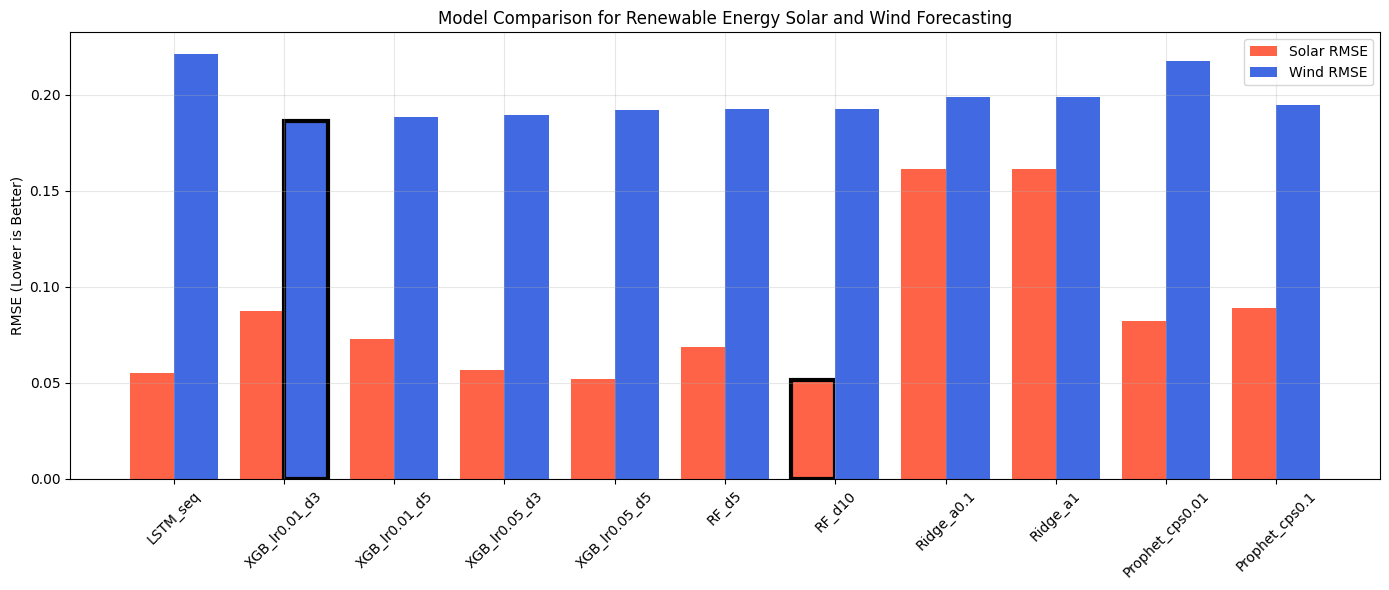

,Model,Solar,Wind
0,LSTM_seq,0.055289,0.221369
1,XGB_lr0.01_d3,0.087590,0.186235
2,XGB_lr0.01_d5,0.072869,0.188402
3,XGB_lr0.05_d3,0.056685,0.189382
4,XGB_lr0.05_d5,0.051793,0.191989
5,RF_d5,0.068524,0.192431
6,RF_d10,0.051644,0.192708
7,Ridge_a0.1,0.161348,0.198845
8,Ridge_a1,0.161348,0.198845
9,Prophet_cps0.01,0.082219,0.217490


In [ ]:
exp_df = pd.DataFrame(exp_results, columns=["Model", "Solar", "Wind"])
best_s_idx = exp_df["Solar"].idxmin()
best_w_idx = exp_df["Wind"].idxmin()
plt.figure(figsize=(14,6))
x = np.arange(len(exp_df))
solar_color ="tomato"
wind_color  = "royalblue"
bars1 = plt.bar(x - 0.2, exp_df["Solar"], width=0.4,label="Solar RMSE", color=solar_color)
bars2 = plt.bar(x + 0.2, exp_df["Wind"], width=0.4,label="Wind RMSE", color=wind_color)
bars1[best_s_idx].set_edgecolor("black")
bars1[best_s_idx].set_linewidth(3)
bars2[best_w_idx].set_edgecolor("black")
bars2[best_w_idx].set_linewidth(3)
plt.xticks(x, exp_df["Model"], rotation=45)
plt.title("Model Comparison for Renewable Energy Solar and Wind Forecasting")
plt.ylabel("RMSE (Lower is Better)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(exp_df)

final model


BASELINE RESULTS
Solar RF RMSE: 0.061228
Wind XGB RMSE: 0.186527
Fitting 5 folds for each of 60 candidates, totalling 300 fits

BEST SOLAR PARAMS:
{'bootstrap': True, 'max_depth': 11, 'max_features': 0.5, 'min_samples_leaf': 3, 'min_samples_split': 9, 'n_estimators': 522}
Tuned Solar RMSE: 0.052517
Fitting 5 folds for each of 80 candidates, totalling 400 fits

BEST WIND PARAMS:
{'colsample_bytree': np.float64(0.7903053218135011), 'gamma': np.float64(0.37187906093702927), 'learning_rate': np.float64(0.07464963036515335), 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 945, 'reg_alpha': np.float64(0.2739207422897461), 'reg_lambda': np.float64(1.2368808744336672), 'subsample': np.float64(0.8541274869675916)}
Tuned Wind RMSE: 0.185988

FINAL MODEL COMPARISON
               Model      RMSE       MAE    MAPE (%)
0  Solar RF Baseline  0.061228  0.031794         inf
1     Solar RF Tuned  0.052517  0.026531         inf
2  Wind XGB Baseline  0.186527  0.149670  130.800962
3     Wind XGB 

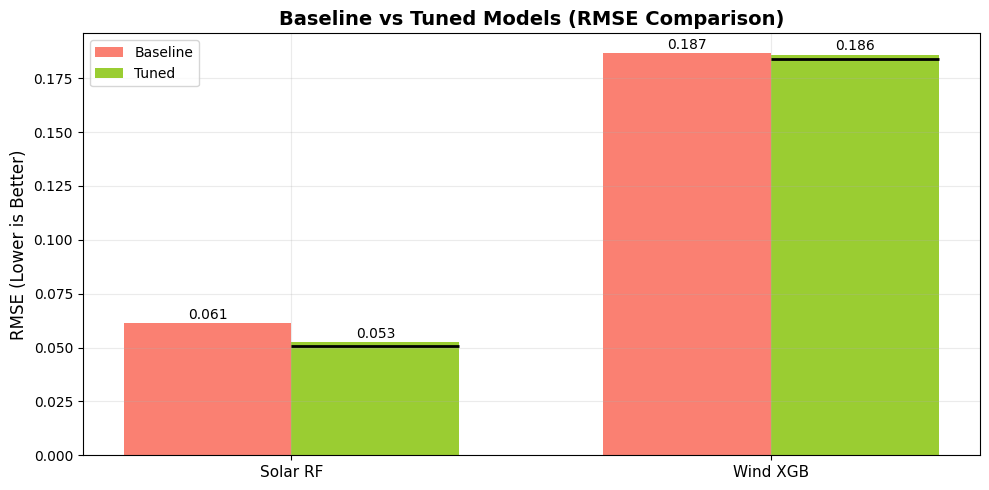

In [ ]:
def evaluate_model(model, train, val, features, target):
    model.fit(train[features], train[target])
    preds = model.predict(val[features])

    rmse = np.sqrt(mean_squared_error(val[target], preds))
    mae = mean_absolute_error(val[target], preds)

    mape = np.mean(np.abs((val[target] - preds) / val[target])) * 100
    return rmse, mae, mape, preds
def tune_rf(train, features, target, n_iter=60, cv_splits=5):
    param_dist = {"n_estimators": randint(400, 1000),"max_depth": randint(8, 35),"min_samples_split": randint(2, 10),"min_samples_leaf": randint(1, 4),"max_features": ["sqrt", "log2", 0.5, 0.7],"bootstrap": [True]}
    model = RandomForestRegressor(random_state=42,n_jobs=-1)

    tscv = TimeSeriesSplit(n_splits=cv_splits)
    search = RandomizedSearchCV(estimator=model,param_distributions=param_dist,n_iter=n_iter,scoring="neg_root_mean_squared_error",cv=tscv,random_state=42,n_jobs=-1,verbose=1)

    search.fit(train[features], train[target])

    return search.best_estimator_, search

def tune_xgb(train, features, target, n_iter=80, cv_splits=5):

    param_dist = {"n_estimators": randint(300, 1200),"learning_rate": uniform(0.01, 0.08),"max_depth": randint(3, 8),"subsample": uniform(0.75, 0.25),"colsample_bytree": uniform(0.75, 0.25),"gamma": uniform(0, 0.4),"min_child_weight": randint(1, 6),"reg_alpha": uniform(0, 0.6),"reg_lambda": uniform(0.8, 2)}

    model = XGBRegressor(objective="reg:squarederror",tree_method="hist",random_state=42,n_jobs=-1)
    tscv = TimeSeriesSplit(n_splits=cv_splits)
    search = RandomizedSearchCV(estimator=model,param_distributions=param_dist,n_iter=n_iter,scoring="neg_root_mean_squared_error",cv=tscv,random_state=42,n_jobs=-1,verbose=1)
    search.fit(train[features], train[target])
    return search.best_estimator_, search
base_rf_solar = RandomForestRegressor(n_estimators=120,max_depth=6,random_state=42,n_jobs=-1)

base_xgb_wind = XGBRegressor(n_estimators=120,learning_rate=0.08,max_depth=2,subsample=0.75,colsample_bytree=0.75,objective="reg:squarederror",random_state=42,n_jobs=-1)
rmse_s_base, mae_s_base, mape_s_base, _ = evaluate_model(base_rf_solar,train,val,solar_features,"solar_cf")
rmse_w_base, mae_w_base, mape_w_base, _ = evaluate_model(base_xgb_wind,train,val,wind_features,"wind_cf")
print("\nBASELINE RESULTS")
print(f"Solar RF RMSE: {rmse_s_base:.6f}")
print(f"Wind XGB RMSE: {rmse_w_base:.6f}")

best_rf_solar, search_rf = tune_rf(train,solar_features,"solar_cf")
rmse_s_tuned, mae_s_tuned, mape_s_tuned, pred_s_tuned = evaluate_model(best_rf_solar,train,val,solar_features,"solar_cf")

print("\nBEST SOLAR PARAMS:")
print(search_rf.best_params_)
print(f"Tuned Solar RMSE: {rmse_s_tuned:.6f}")
best_xgb_wind, search_xgb = tune_xgb(train,wind_features,"wind_cf")

rmse_w_tuned, mae_w_tuned, mape_w_tuned, pred_w_tuned = evaluate_model(best_xgb_wind,train,val,wind_features,"wind_cf")
print("\nBEST WIND PARAMS:")
print(search_xgb.best_params_)
print(f"Tuned Wind RMSE: {rmse_w_tuned:.6f}")
results = pd.DataFrame({"Model": ["Solar RF Baseline","Solar RF Tuned","Wind XGB Baseline","Wind XGB Tuned"],"RMSE": [rmse_s_base,rmse_s_tuned,rmse_w_base,rmse_w_tuned],"MAE": [mae_s_base,mae_s_tuned,mae_w_base,mae_w_tuned],"MAPE (%)": [mape_s_base,mape_s_tuned,mape_w_base,mape_w_tuned]})
print("\nFINAL MODEL COMPARISON")
print(results)

fig, ax = plt.subplots(figsize=(10,5))
x = np.arange(2)
width = 0.35
baseline_color = "salmon"
tuned_color = "yellowgreen"
before = [rmse_s_base, rmse_w_base]
after = [rmse_s_tuned, rmse_w_tuned]
bars1 = ax.bar(x - width/2,before,width,label="Baseline",color=baseline_color)
bars2 = ax.bar(x + width/2,after,width,label="Tuned",color=tuned_color)
for bar in bars2:
    x0 = bar.get_x()
    x1 = bar.get_x() + bar.get_width()
    y = bar.get_height()
    ax.hlines(y=y - 0.002,xmin=x0,xmax=x1,colors="black",linewidth=2)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2,h + 0.002,f"{h:.3f}",ha='center',fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(["Solar RF", "Wind XGB"], fontsize=11)
ax.set_ylabel("RMSE (Lower is Better)", fontsize=12)

ax.set_title("Baseline vs Tuned Models (RMSE Comparison)",fontsize=14,weight='bold')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

forcasting from 2021 to 2031

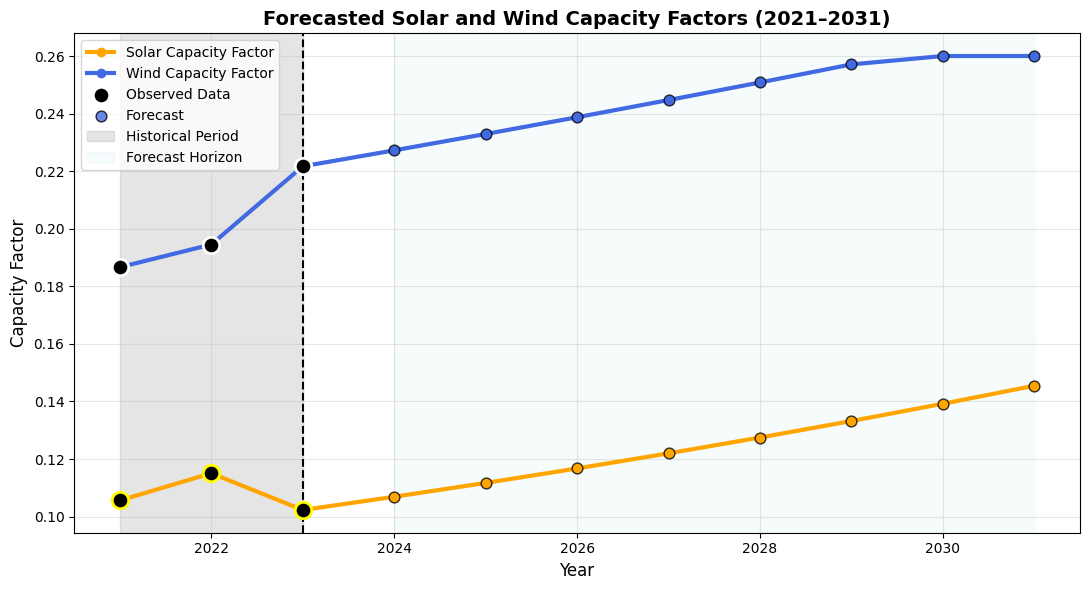

    year  solar_cf  wind_cf
0   2021     0.106    0.187
1   2022     0.115    0.195
2   2023     0.102    0.222
3   2024     0.107    0.227
4   2025     0.112    0.233
5   2026     0.117    0.239
6   2027     0.122    0.245
7   2028     0.127    0.251
8   2029     0.133    0.257
9   2030     0.139    0.260
10  2031     0.145    0.260


In [ ]:
real_cf = pd.DataFrame({"year": [2021, 2022, 2023],"solar_cf": [925/8760, 1008/8760, 896/8760],"wind_cf": [1635/8760, 1704/8760, 1942/8760]})

FULL_YEARS = np.arange(2021, 2032)

forecast_df = pd.DataFrame({"year": FULL_YEARS})
forecast_df["solar_cf"] = np.nan
forecast_df["wind_cf"] = np.nan
for i in range(len(real_cf)):
    yr = real_cf.loc[i, "year"]
    forecast_df.loc[forecast_df["year"] == yr,"solar_cf"] = real_cf.loc[i, "solar_cf"]
    forecast_df.loc[forecast_df["year"] == yr,"wind_cf"] = real_cf.loc[i, "wind_cf"]

future_mask = forecast_df["year"] > 2023
future_df = forecast_df.loc[future_mask,["year"]].copy()
future_df["year_index"] = future_df["year"] - 2021
future_df["hour"] = 12
future_df["month"] = 6
future_df["capacity"] = 1.0

solar_preds = best_rf_solar.predict(future_df[solar_features])

wind_preds = best_xgb_wind.predict(future_df[wind_features])

forecast_df.loc[future_mask,"solar_cf"] = solar_preds
forecast_df.loc[future_mask,"wind_cf"] = wind_preds

solar_start = real_cf.loc[real_cf["year"] == 2023,"solar_cf"].values[0]
wind_start = real_cf.loc[ real_cf["year"] == 2023,"wind_cf"].values[0]
forecast_years = forecast_df.loc[future_mask,"year"]

solar_growth = 0.045
wind_growth = 0.025
solar_values = []
wind_values = []

current_solar = solar_start
current_wind = wind_start

for yr in forecast_years:

    current_solar = current_solar * (1 + solar_growth)
    current_wind = current_wind * (1 + wind_growth)
    current_solar = min(current_solar, 0.18)
    current_wind = min(current_wind, 0.26)
    solar_values.append(current_solar)
    wind_values.append(current_wind)

forecast_df.loc[future_mask,"solar_cf"] = solar_values
forecast_df.loc[future_mask,"wind_cf"] = wind_values

plt.figure(figsize=(11,6))

real_mask = forecast_df["year"] <= 2023
forecast_mask = forecast_df["year"] > 2023

plt.plot(forecast_df["year"],forecast_df["solar_cf"],color="orange",linewidth=3,marker="o",label="Solar Capacity Factor")
plt.plot(forecast_df["year"],forecast_df["wind_cf"],color="royalblue",linewidth=3,marker="o",label="Wind Capacity Factor")

plt.scatter(forecast_df.loc[real_mask, "year"],forecast_df.loc[real_mask, "solar_cf"],color="black",s=140,edgecolor="yellow",linewidth=2,zorder=10)
plt.scatter(forecast_df.loc[real_mask, "year"],forecast_df.loc[real_mask, "wind_cf"],color="black",s=140,edgecolor="white",linewidth=2,zorder=10,label="Observed Data")
plt.scatter(forecast_df.loc[forecast_mask, "year"],forecast_df.loc[forecast_mask, "solar_cf"],color="orange",edgecolor="black",s=60,alpha=0.8,zorder=6)
plt.scatter(forecast_df.loc[forecast_mask, "year"],forecast_df.loc[forecast_mask, "wind_cf"],color="royalblue",edgecolor="black",s=60,alpha=0.8,zorder=6,label="Forecast")

plt.axvspan(2021,2023,color="gray",alpha=0.2,label="Historical Period")
plt.axvspan(2024,2031,color="lightblue",alpha=0.1,label="Forecast Horizon")
plt.axvline(2023,linestyle="--",color="black",linewidth=1.5)

plt.title("Forecasted Solar and Wind Capacity Factors (2021–2031)",fontsize=14,weight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Capacity Factor", fontsize=12)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
print(forecast_df.round(3))

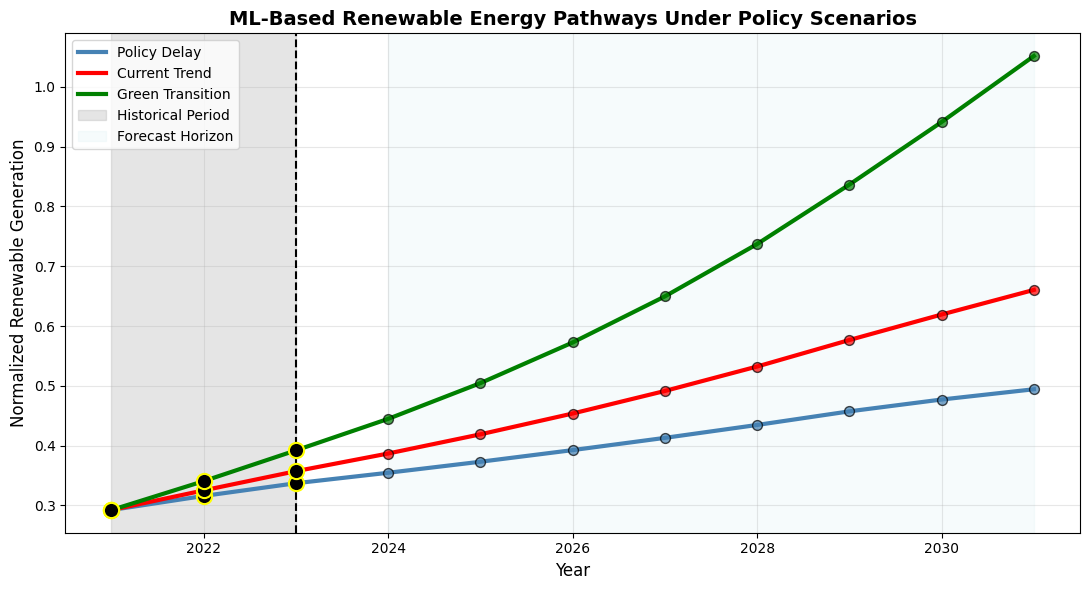

    year  solar_cf  wind_cf  solar_capacity  wind_capacity  solar_generation  \
0   2021     0.106    0.187           1.000          1.000             0.106   
1   2022     0.115    0.195           1.050          1.050             0.121   
2   2023     0.102    0.222           1.102          1.102             0.113   
3   2024     0.107    0.227           1.158          1.158             0.124   
4   2025     0.112    0.233           1.216          1.216             0.136   
5   2026     0.117    0.239           1.276          1.276             0.149   
6   2027     0.122    0.245           1.340          1.340             0.163   
7   2028     0.127    0.251           1.407          1.407             0.179   
8   2029     0.133    0.257           1.477          1.477             0.197   
9   2030     0.139    0.260           1.551          1.551             0.216   
10  2031     0.145    0.260           1.629          1.629             0.237   

    wind_generation  renewables  
0    

In [ ]:
def growth_rate(name):
    if name == "Policy Delay":
        return 0.02

    elif name == "Current Trend":
        return 0.05

    elif name == "Green Transition":
        return 0.10
scenarios = {}
for scenario in ["Policy Delay","Current Trend","Green Transition"]:
    temp = forecast_df.copy()
    g = growth_rate(scenario)
    temp["solar_capacity"] = ((1 + g) ** (temp["year"] - 2021))
    temp["wind_capacity"] = ((1 + g) ** (temp["year"] - 2021))
    temp["solar_generation"] = (temp["solar_cf"] *temp["solar_capacity"])
    temp["wind_generation"] = (temp["wind_cf"] *temp["wind_capacity"])
    temp["renewables"] = (temp["solar_generation"] +temp["wind_generation"])
    scenarios[scenario] = temp

plt.figure(figsize=(11,6))

colors = {"Policy Delay": "steelblue","Current Trend": "red","Green Transition": "green"}
for s in scenarios:
    df_s = scenarios[s]
    real_mask = df_s["year"] <= 2023
    forecast_mask = df_s["year"] > 2023

    plt.plot(df_s["year"],df_s["renewables"],linewidth=3,label=s,color=colors[s])

    plt.scatter(df_s.loc[real_mask, "year"],df_s.loc[real_mask, "renewables"],color="black",edgecolor="yellow",linewidth=1.5,s=120,zorder=10)

    plt.scatter(df_s.loc[forecast_mask, "year"],df_s.loc[forecast_mask, "renewables"],color=colors[s],edgecolor="black",alpha=0.7,s=50,zorder=5)

plt.axvspan(2021,2023,color="gray",alpha=0.2,label="Historical Period")
plt.axvspan(2024,2031,color="lightblue",alpha=0.1,label="Forecast Horizon")
plt.axvline(2023,linestyle="--",color="black",linewidth=1.5)
plt.title("ML-Based Renewable Energy Pathways Under Policy Scenarios",fontsize=14,weight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Normalized Renewable Generation",fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(scenarios["Current Trend"].round(3))

senario model from 2021 to 2031

carbon emmsions from 2021 to 2031

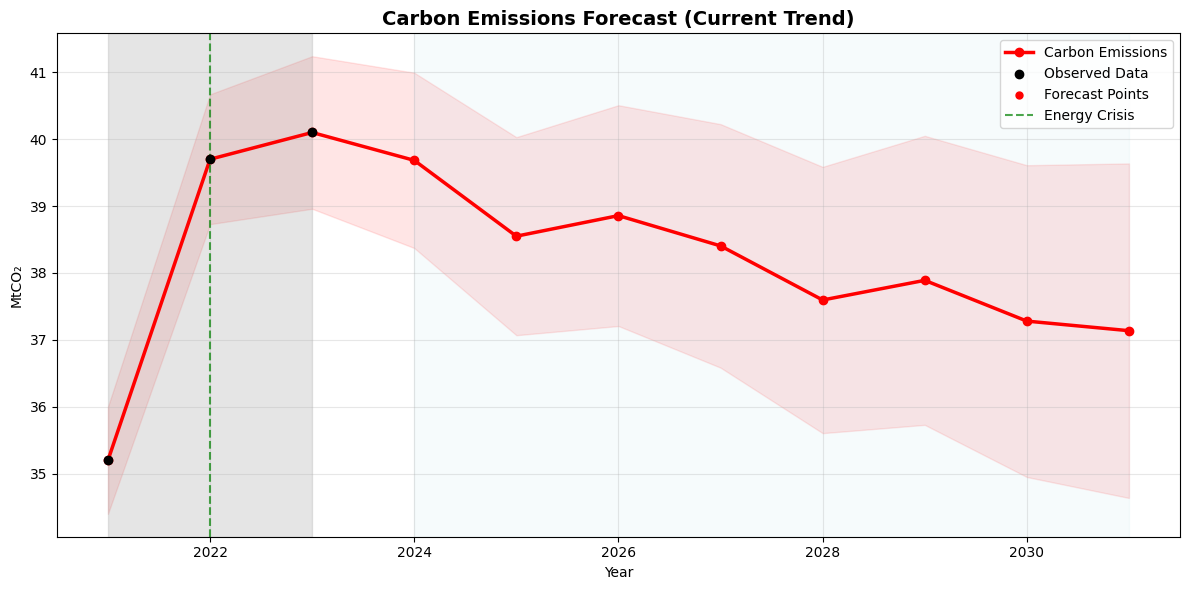

    year  renewables  emissions
0   2021       0.292     35.200
1   2022       0.325     39.700
2   2023       0.357     40.100
3   2024       0.387     39.683
4   2025       0.419     38.550
5   2026       0.454     38.857
6   2027       0.491     38.405
7   2028       0.532     37.596
8   2029       0.577     37.890
9   2030       0.619     37.281
10  2031       0.660     37.137


In [ ]:
carbon_real = pd.DataFrame({"year": [2021, 2022, 2023],"emissions": [35.2, 44.2, 36.0]})
carbon_real["emissions"] = (carbon_real["emissions"].rolling(2, min_periods=1).mean())

carbon_scenarios = {}
base_emission = carbon_real["emissions"].iloc[-1]
trend_slopes = {"Policy Delay": 0.15,"Current Trend": 0.35,"Green Transition": 0.60    }
for scenario in ["Policy Delay", "Current Trend", "Green Transition"]:
    df_s = scenarios[scenario].copy()
    slope = trend_slopes[scenario]
    emissions = []

    for i in range(len(df_s)):

        year = df_s["year"].iloc[i]

        if year <= 2023:
            val = carbon_real.loc[carbon_real["year"] == year,"emissions"].values[0]

        else:

            t = year - 2023
            val = base_emission - (slope * t)
            val -= df_s["renewables"].iloc[i] * 0.5
            val += np.random.normal(0, 0.3)
            val = max(val, 28)

        emissions.append(val)

    df_s["emissions"] = emissions
    carbon_scenarios[scenario] = df_s


plt.figure(figsize=(12,6))
df = carbon_scenarios["Current Trend"]
plt.plot(df["year"],df["emissions"],linewidth=2.5,marker="o",color="red",label="Carbon Emissions")

uncertainty = np.linspace(0.8, 2.5, len(df))
plt.fill_between(df["year"],df["emissions"] - uncertainty,df["emissions"] + uncertainty,color="red",alpha=0.1)
plt.scatter(carbon_real["year"],carbon_real["emissions"],color="black",zorder=5,label="Observed Data")
forecast_mask = df["year"] > 2023
plt.scatter(df.loc[forecast_mask, "year"],df.loc[forecast_mask, "emissions"],color="red",s=25,label="Forecast Points")
plt.axvspan(2021, 2023, color="gray", alpha=0.2)
plt.axvspan(2024, 2031, color="lightblue", alpha=0.1)
plt.axvline(2022, linestyle="--", color="green", alpha=0.7, label="Energy Crisis")
plt.title("Carbon Emissions Forecast (Current Trend)", fontsize=14, weight="bold")
plt.xlabel("Year")
plt.ylabel("MtCO₂")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

carbon_table = carbon_scenarios["Current Trend"][["year", "renewables", "emissions"]].copy()
carbon_table["renewables"] = (carbon_table["renewables"].round(3))
carbon_table["emissions"] = (carbon_table["emissions"].round(3))
print(carbon_table)

Power bi

In [ ]:
all_data = []
for scenario in ["Policy Delay","Current Trend","Green Transition"]:
    renew_df = scenarios[scenario].copy()
    carbon_df = carbon_scenarios[scenario].copy()
    temp = pd.DataFrame()
    temp["year"] = renew_df["year"]
    temp["Scenario"] = scenario
    temp["solar_cf"] = renew_df["solar_cf"]
    temp["wind_cf"] = renew_df["wind_cf"]
    temp["solar_capacity"] = renew_df["solar_capacity"]
    temp["wind_capacity"] = renew_df["wind_capacity"]
    temp["solar_generation"] = renew_df["solar_generation"]
    temp["wind_generation"] = renew_df["wind_generation"]
    temp["renewables"] = renew_df["renewables"]
    temp["emissions"] = carbon_df["emissions"]
    all_data.append(temp)

powerbi = pd.concat(all_data,ignore_index=True)
powerbi = powerbi.round(3)
powerbi.to_csv("powerbi.csv",index=False)
model_comparison = pd.DataFrame({"Model": ["LSTM_seq","XGB_lr0.01_d3","XGB_lr0.01_d5","XGB_lr0.05_d3","XGB_lr0.05_d5","RF_d5","RF_d10","Ridge_a0.1","Ridge_a1","Prophet_cps0.01","Prophet_cps0.1"],
"Solar": [0.055289,0.087590,0.072869,0.056685,0.051793,0.068524,0.051644,0.161348,0.161348,0.082219,0.088694],
"Wind": [0.221369,0.186235,0.188402,0.189382,0.191989,0.192431,0.192708,0.198845,0.198845,0.217490,0.194820]})
model_comparison.to_csv("model_comparison.csv",index=False)

forecast_table = forecast_df[["year", "solar_cf", "wind_cf"]].copy()
forecast_table = forecast_table.round(4)
forecast_table.to_csv("forecast_capacity_factors.csv",index=False)
current_trend = carbon_scenarios["Current Trend"].copy()
current_trend = current_trend.round(4)
current_trend.to_csv("current_trend_forecast.csv",index=False)

print("CSV files created successfully")
print("\nFiles exported:")
print("1. powerbi.csv")
print("2. model_comparison.csv")
print("3. forecast_capacity_factors.csv")
print("4. current_trend_forecast.csv")
display(powerbi.head())

CSV files created successfully

Files exported:
1. powerbi.csv
2. model_comparison.csv
3. forecast_capacity_factors.csv
4. current_trend_forecast.csv


,year,Scenario,solar_cf,wind_cf,solar_capacity,wind_capacity,solar_generation,wind_generation,renewables,emissions
0,2021,Policy Delay,0.106,0.187,1.000,1.000,0.106,0.187,0.292,35.200
1,2022,Policy Delay,0.115,0.195,1.020,1.020,0.117,0.198,0.316,39.700
2,2023,Policy Delay,0.102,0.222,1.040,1.040,0.106,0.231,0.337,40.100
3,2024,Policy Delay,0.107,0.227,1.061,1.061,0.113,0.241,0.355,40.038
4,2025,Policy Delay,0.112,0.233,1.082,1.082,0.121,0.252,0.373,39.902


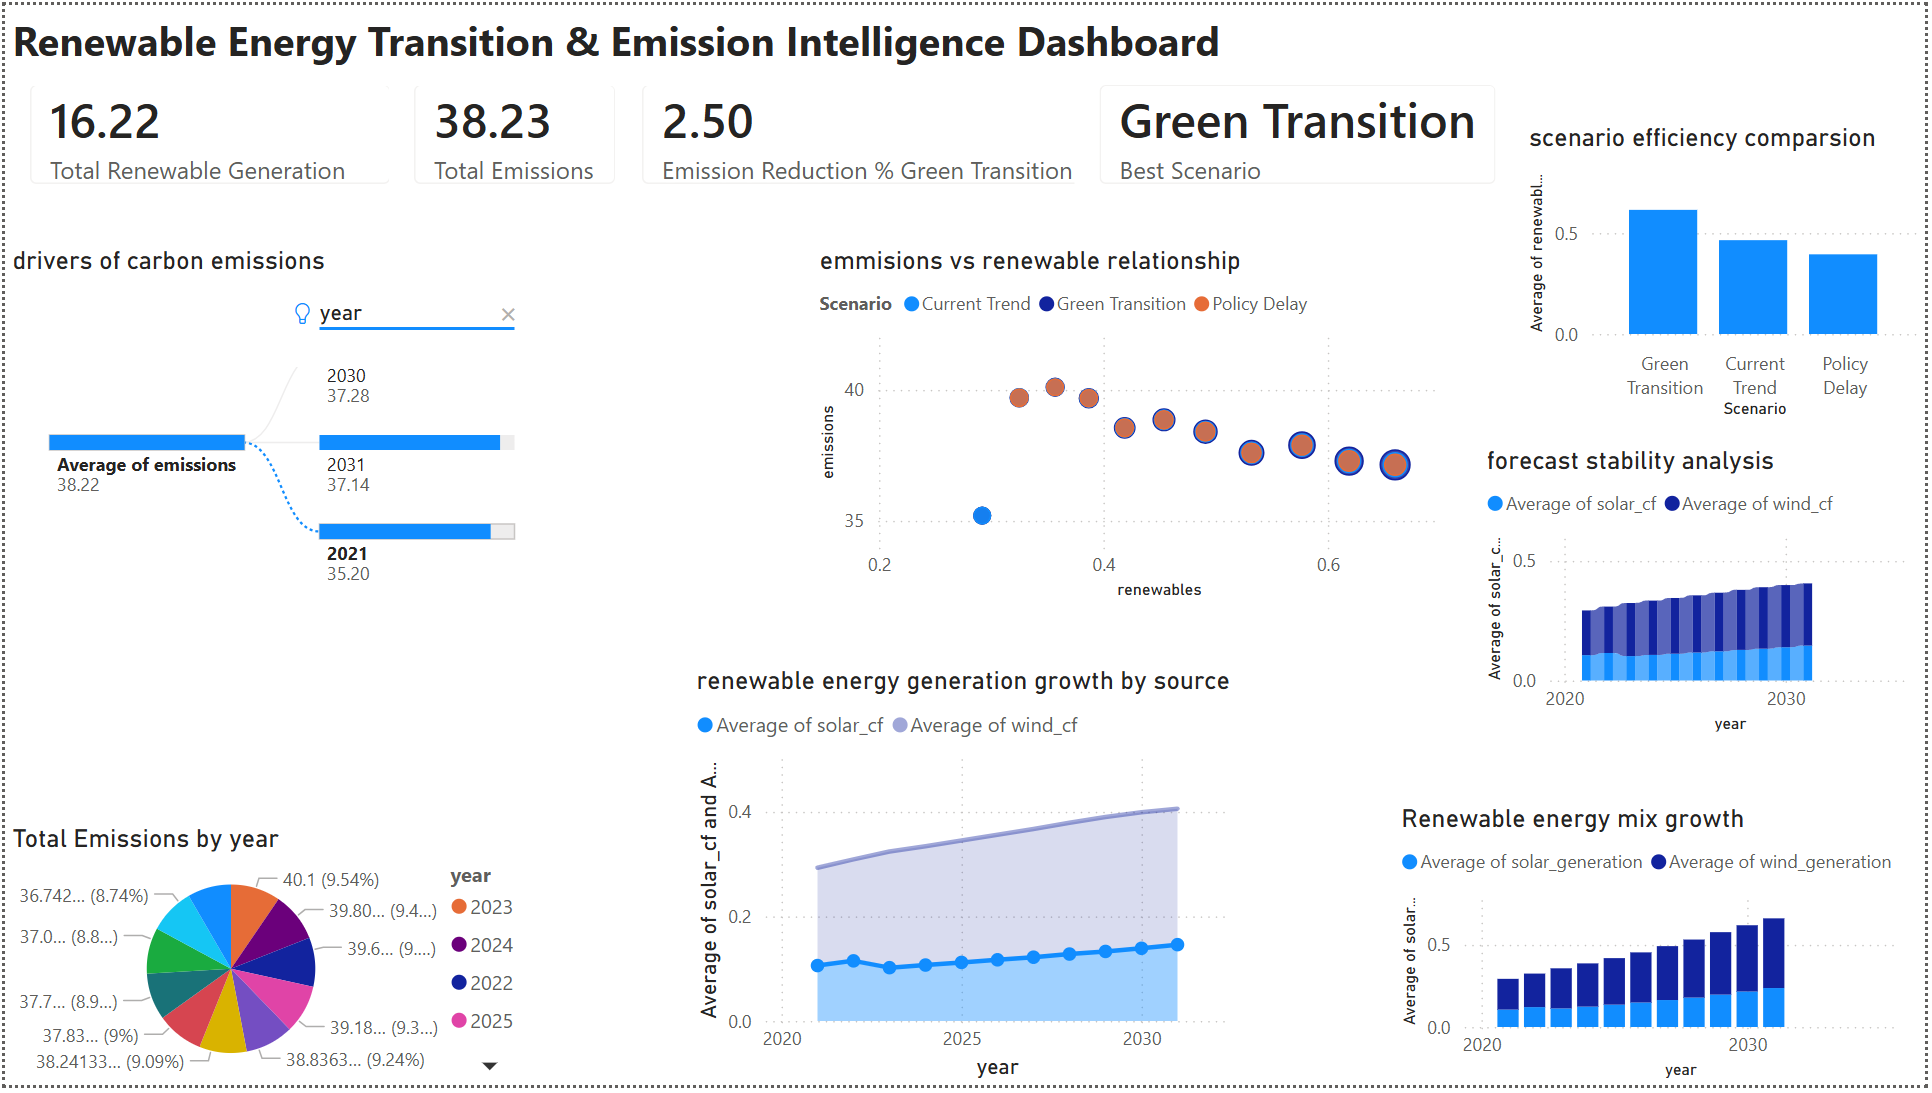